# Exploratory Data Analysis (EDA)

**Input  :** `data/silver/` — cleaned files
**Output :** `reports/eda_summary.json` — key findings 
**Charts :** `reports/figures/` — all plots saved as PNG

---

## Sections

| Section | Question answered |
|---------|------------------|
| A | Dataset overview — shapes, memory, unique IDs |
| B | Volume distribution — histogram, box plot, monthly trends |
| C | Outlet analysis — top/bottom outlets, CV, max/mean ratio |
| D | Outlet master — type/size breakdown, cooler vs volume |
| E | Seasonality — do the labels match actual volume? |
| F | Holidays — which months are most disrupted? |
| G | Censoring summary — how much data is likely constrained? |

## Rule
> Every chart answers a specific question. No decoration.

## Imports

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.eda_utils import (
    dataset_overview,
    plot_volume_distribution,
    plot_volume_by_month,
    compute_outlet_stats,
    plot_outlet_cv_distribution,
    plot_top_bottom_outlets,
    plot_outlet_categorical_breakdown,
    plot_cooler_vs_volume,
    plot_seasonality_index_distribution,
    plot_volume_by_seasonality,
    plot_holidays_per_month,
    censoring_signal_summary,
)

print("Imports OK")
print(f"Pandas     : {pd.__version__}")
print(f"Matplotlib : {plt.matplotlib.__version__}")

Imports OK
Pandas     : 3.0.3
Matplotlib : 3.10.9


## Configuration

In [2]:
from src.configs.config import config
from src.utils.io import read_parquet

os.makedirs(config.FIGURES_DIR, exist_ok=True)
os.makedirs(config.REPORTS_DIR, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

eda_findings = {
    "phase": "EDA",
    "run_timestamp": datetime.now().isoformat(),
    "findings": {},
}


def save_fig(fig, name):
    path = os.path.join(config.FIGURES_DIR, f"{name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")
    return path


print(f"Config loaded. Figures -> {config.FIGURES_DIR}")

Config loaded. Figures -> C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures


## Load Silver Files

In [3]:
silver_path = config.SILVER_PATH

tx = read_parquet(silver_path, "transactions_history_final")
out = read_parquet(silver_path, "outlet_master")
dist = read_parquet(silver_path, "distributor_seasonality_details")
hol = read_parquet(silver_path, "holiday_list")

hol["Date"] = pd.to_datetime(hol["Date"], errors="coerce")

print("Silver files loaded:")
print(f"  transactions            : {tx.shape[0]:>8,} rows x {tx.shape[1]} cols")
print(f"  outlet_master           : {out.shape[0]:>8,} rows x {out.shape[1]} cols")
print(f"  distributor_seasonality : {dist.shape[0]:>8,} rows x {dist.shape[1]} cols")
print(f"  holiday_list            : {hol.shape[0]:>8,} rows x {hol.shape[1]} cols")

Silver files loaded:
  transactions            : 2,376,388 rows x 12 cols
  outlet_master           :   20,000 rows x 8 cols
  distributor_seasonality :      360 rows x 7 cols
  holiday_list            :      349 rows x 8 cols


---
## Section A — Dataset Overview

In [4]:
frames = {
    "transactions": tx,
    "outlet_master": out,
    "distributor_seasonality": dist,
    "holiday_list": hol,
}

overview = dataset_overview(frames)
display(overview)

eda_findings["findings"]["dataset_overview"] = overview.to_dict(orient="records")

,dataset,rows,columns,memory_kb,null_count,null_pct
0,transactions,2376388,12,369454.8,0,0.0
1,outlet_master,20000,8,2548.3,0,0.0
2,distributor_seasonality,360,7,44.7,0,0.0
3,holiday_list,349,8,52.2,0,0.0


### A2 — Unique ID Counts

How many distinct outlets, distributors, and SKUs are we working with?

In [5]:
id_counts = {
    "Unique Outlet_IDs in transactions": tx["Outlet_ID"].nunique(),
    "Unique Outlet_IDs in outlet_master": out["Outlet_ID"].nunique(),
    "Unique Distributor_IDs": tx["Distributor_ID"].nunique(),
    "Unique SKU_IDs": tx["SKU_ID"].nunique(),
    "Year range": f"{tx['Year'].min()} to {tx['Year'].max()}",
    "Months covered": tx["Month"].nunique(),
    "Total holidays in dataset": len(hol),
}

for k, v in id_counts.items():
    print(f"  {k:<45} {str(v):>10}")

eda_findings["findings"]["id_counts"] = {k: str(v) for k, v in id_counts.items()}

  Unique Outlet_IDs in transactions                  20000
  Unique Outlet_IDs in outlet_master                 20000
  Unique Distributor_IDs                                10
  Unique SKU_IDs                                        10
  Year range                                    2023 to 2025
  Months covered                                        12
  Total holidays in dataset                            349


---
## Section B — Volume Distribution

**Question:** What does the shape of sales volume look like?
Is it normally distributed, skewed, or bimodal? Are there extreme outliers?

In [6]:
nonzero_vol = tx[tx["Volume_Liters"] > 0]["Volume_Liters"]

vol_stats = {
    "total_rows": len(tx),
    "zero_volume_rows": int((tx["Volume_Liters"] == 0).sum()),
    "nonzero_rows": int((tx["Volume_Liters"] > 0).sum()),
    "mean": round(nonzero_vol.mean(), 2),
    "median": round(nonzero_vol.median(), 2),
    "std": round(nonzero_vol.std(), 2),
    "min": round(nonzero_vol.min(), 2),
    "max": round(nonzero_vol.max(), 2),
    "p95": round(nonzero_vol.quantile(0.95), 2),
    "p99": round(nonzero_vol.quantile(0.99), 2),
}

print("Volume_Liters Summary (non-zero rows only)\n")
for k, v in vol_stats.items():
    print(f"  {k:<25} {str(v):>12}")

zero_pct = 100 * vol_stats["zero_volume_rows"] / vol_stats["total_rows"]
print(
    f"\nZero-volume rows: {vol_stats['zero_volume_rows']:,} ({zero_pct:.1f}% of all transactions)"
)
print("These are potential censoring events.")

eda_findings["findings"]["volume_stats"] = vol_stats

Volume_Liters Summary (non-zero rows only)

  total_rows                     2376388
  zero_volume_rows                   100
  nonzero_rows                   2376288
  mean                             52.83
  median                           23.22
  std                              95.18
  min                               1.24
  max                            1233.05
  p95                              197.4
  p99                             554.39

Zero-volume rows: 100 (0.0% of all transactions)
These are potential censoring events.


  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\B1_volume_distribution.png


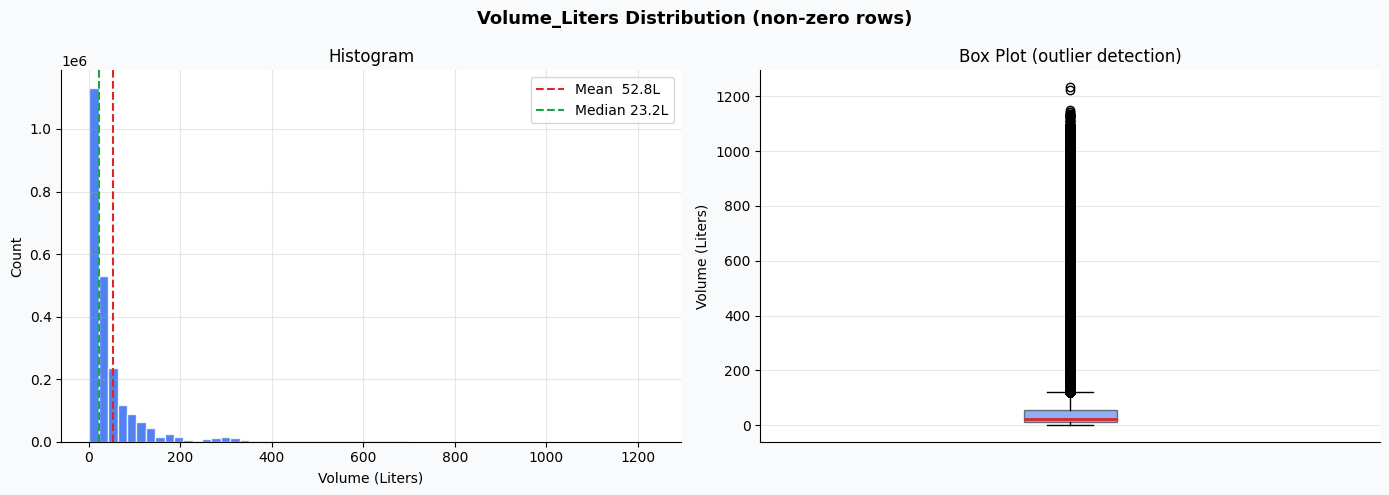

In [7]:
fig = plot_volume_distribution(tx)
save_fig(fig, "B1_volume_distribution")
plt.show()

### B2 — Monthly Volume Trend

**Question:** Is there a seasonal pattern? Does January tend to be high or low?

  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\B2_volume_by_month.png


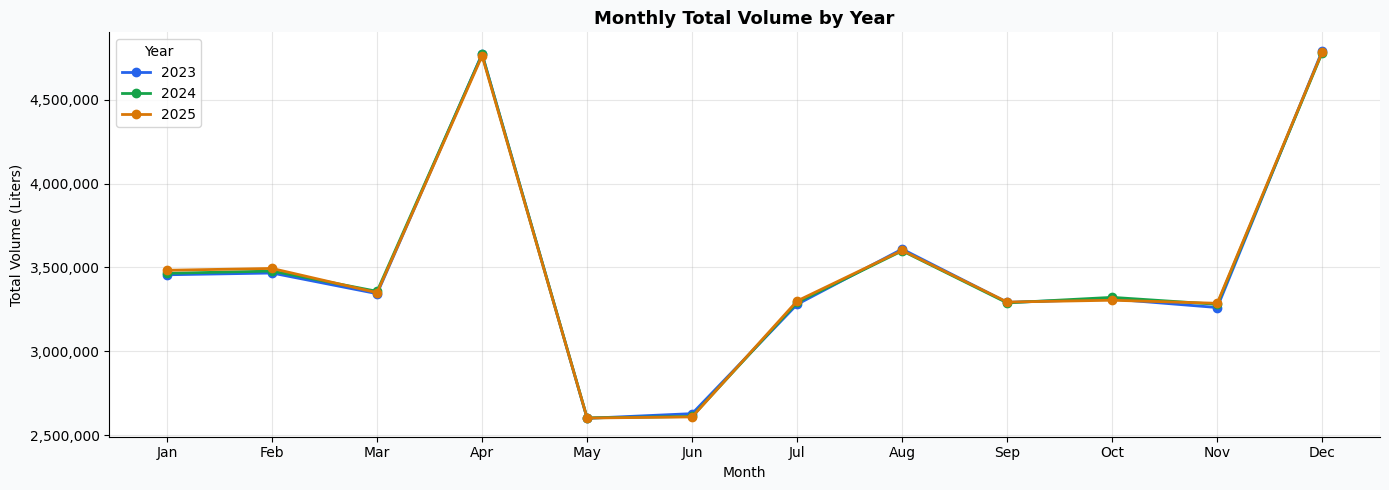

January average volume : 52.7 L
January rank by volume : 5 out of 12 months


In [8]:
fig = plot_volume_by_month(tx)
save_fig(fig, "B2_volume_by_month")
plt.show()

jan_avg = tx[tx["Month"] == 1]["Volume_Liters"].mean()
all_monthly_avg = (
    tx.groupby("Month")["Volume_Liters"].mean().sort_values(ascending=False)
)
jan_rank = all_monthly_avg.index.tolist().index(1) + 1

print(f"January average volume : {jan_avg:,.1f} L")
print(f"January rank by volume : {jan_rank} out of 12 months")
eda_findings["findings"]["january_volume_rank"] = jan_rank

---
## Section C — Outlet-Level Analysis

**Question:** Which outlets dominate volume? Are some outlets suspiciously flat (censored)?

In [9]:
outlet_stats = compute_outlet_stats(tx)

print(f"Outlet stats computed for {len(outlet_stats):,} outlets")
print("\nTop 5 rows:")
display(outlet_stats.head())
print("\nSummary statistics:")
display(outlet_stats.describe().round(2))

Outlet stats computed for 20,000 outlets

Top 5 rows:


,Outlet_ID,total_volume,mean_volume,max_volume,min_volume,std_volume,months_active,zero_volume_months,cv,ratio_max_to_mean,trend_slope
0,OUT_00001,15079.923325,64.444117,461.115768,8.259629,84.721554,234,0,1.314651,7.155281,0.081373
1,OUT_00002,17103.426781,70.096011,475.491288,9.960387,91.344877,244,0,1.303139,6.783429,0.055099
2,OUT_00003,14745.357270,61.184055,461.997334,8.825542,81.202807,241,0,1.327189,7.550943,-0.056448
3,OUT_00004,17997.723550,67.407204,509.374606,9.401547,85.308549,267,0,1.265570,7.556679,0.019333
4,OUT_00005,16489.207430,66.757925,513.283861,8.511816,92.586477,247,0,1.386899,7.688733,0.023772



Summary statistics:


,total_volume,mean_volume,max_volume,min_volume,std_volume,months_active,zero_volume_months,cv,ratio_max_to_mean,trend_slope
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,6276.94,32.28,216.68,4.93,41.90,118.82,0.00,1.29,6.40,0.01
std,10733.38,30.29,220.86,4.43,39.59,85.36,0.07,0.09,0.95,0.12
min,109.72,6.64,17.21,0.00,3.83,15.00,0.00,0.56,2.36,-1.29
25%,738.88,13.73,84.69,2.42,17.93,54.00,0.00,1.25,5.75,-0.05
50%,1155.73,18.43,104.42,3.04,23.83,76.00,0.00,1.30,6.46,0.01
75%,4049.85,30.26,200.36,5.21,39.73,143.00,0.00,1.34,7.05,0.06
max,54497.46,150.00,1233.05,27.56,201.90,367.00,1.00,1.88,15.81,1.25


  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\C1_top_bottom_outlets.png


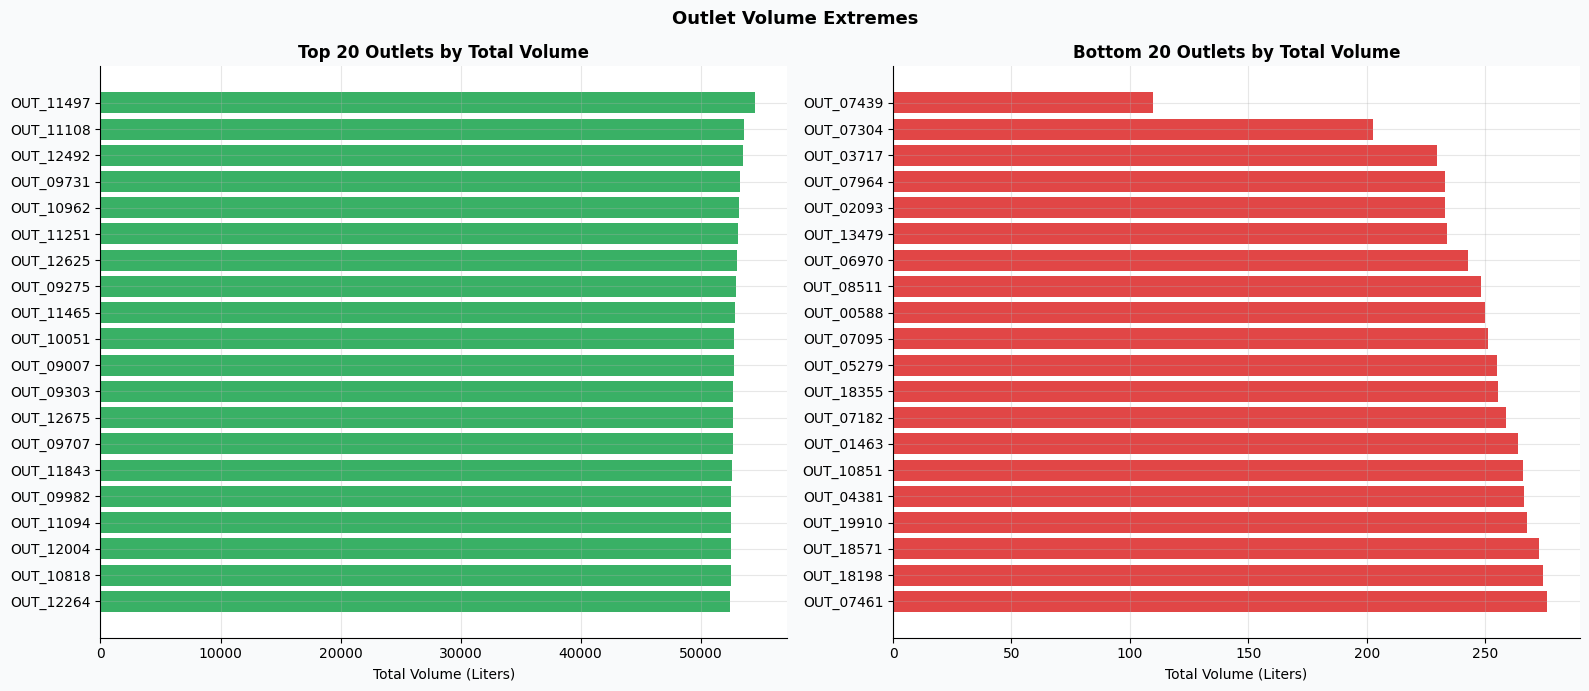

In [10]:
fig = plot_top_bottom_outlets(outlet_stats, n=20)
save_fig(fig, "C1_top_bottom_outlets")
plt.show()

### C2 — Coefficient of Variation (CV)

**Question:** How many outlets have suspiciously flat sales?

CV = std / mean. CV near 0 means near-identical sales every month — a delivery cap signal.
CV > 0.5 means highly variable — possibly intermittent supply.

  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\C2_outlet_cv_distribution.png


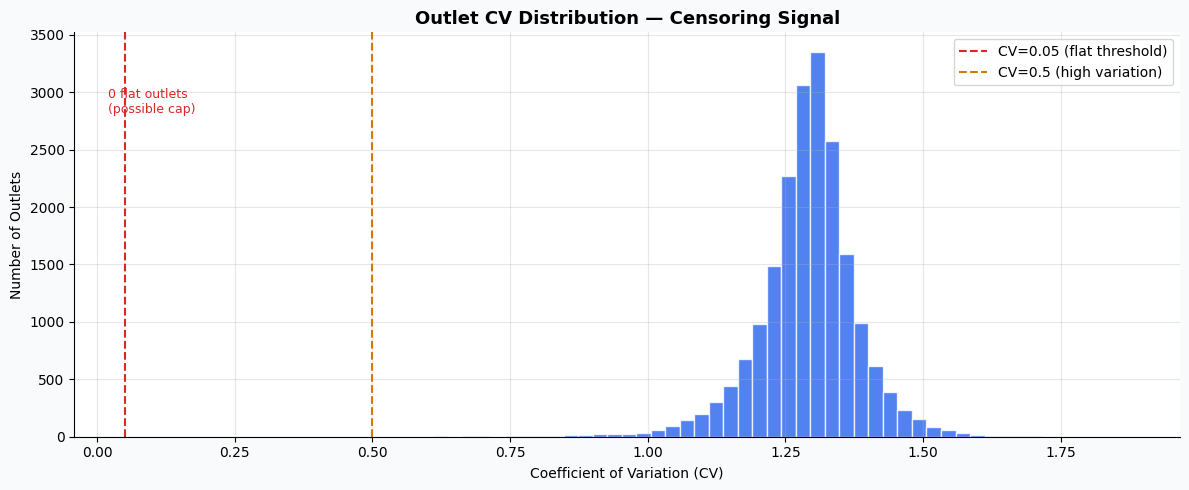

Flat   (CV < 0.05)       : 0  (0.0%)
Normal (0.05 <= CV <= 0.5): 0  (0.0%)
High   (CV > 0.5)        : 20,000  (100.0%)


In [11]:
fig = plot_outlet_cv_distribution(outlet_stats)
save_fig(fig, "C2_outlet_cv_distribution")
plt.show()

flat_n = (outlet_stats["cv"] < 0.05).sum()
normal_n = ((outlet_stats["cv"] >= 0.05) & (outlet_stats["cv"] <= 0.5)).sum()
high_n = (outlet_stats["cv"] > 0.5).sum()
total_out = len(outlet_stats)

print(f"Flat   (CV < 0.05)       : {flat_n:,}  ({100 * flat_n / total_out:.1f}%)")
print(f"Normal (0.05 <= CV <= 0.5): {normal_n:,}  ({100 * normal_n / total_out:.1f}%)")
print(f"High   (CV > 0.5)        : {high_n:,}  ({100 * high_n / total_out:.1f}%)")

eda_findings["findings"]["cv_breakdown"] = {
    "flat_outlets": int(flat_n),
    "normal_outlets": int(normal_n),
    "high_cv_outlets": int(high_n),
}

### C3 — Max/Mean Ratio

**Question:** Did low-average outlets ever sell much more?

max / mean > 3 means the low months were likely constrained.
The maximum is the best available proxy for true potential.

Outlets with max/mean ratio > 3x : 19,990 (100.0%)
  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\C3_max_mean_ratio.png


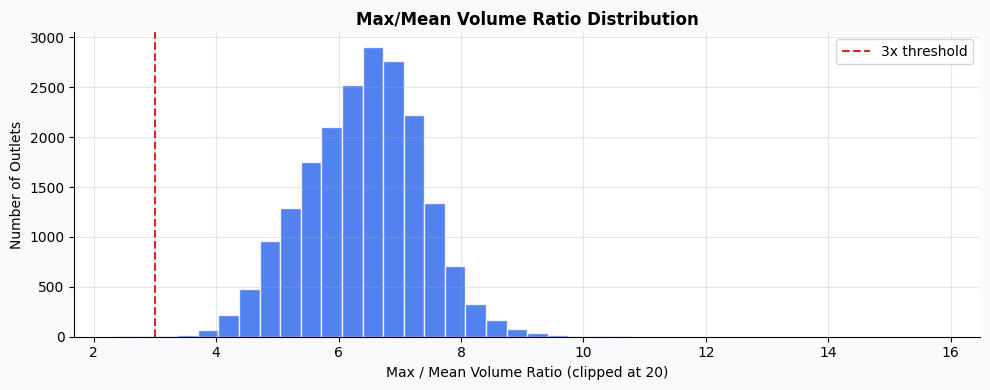

In [12]:
high_ratio = outlet_stats[outlet_stats["ratio_max_to_mean"] > 3].shape[0]
print(
    f"Outlets with max/mean ratio > 3x : {high_ratio:,} ({100 * high_ratio / len(outlet_stats):.1f}%)"
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    outlet_stats["ratio_max_to_mean"].clip(upper=20),
    bins=40,
    color="#2563EB",
    alpha=0.8,
    edgecolor="white",
)
ax.axvline(3, color="#DC2626", linestyle="--", linewidth=1.5, label="3x threshold")
ax.set_xlabel("Max / Mean Volume Ratio (clipped at 20)")
ax.set_ylabel("Number of Outlets")
ax.set_title("Max/Mean Volume Ratio Distribution", fontsize=12, fontweight="bold")
ax.legend()
fig.tight_layout()
save_fig(fig, "C3_max_mean_ratio")
plt.show()

eda_findings["findings"]["high_ratio_outlets"] = int(high_ratio)

---
## Section D — Outlet Master Analysis

**Question 1:** What is the type/size breakdown of outlets?
**Question 2:** Do outlets with more coolers sell more?

  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\D1_outlet_categorical_breakdown.png


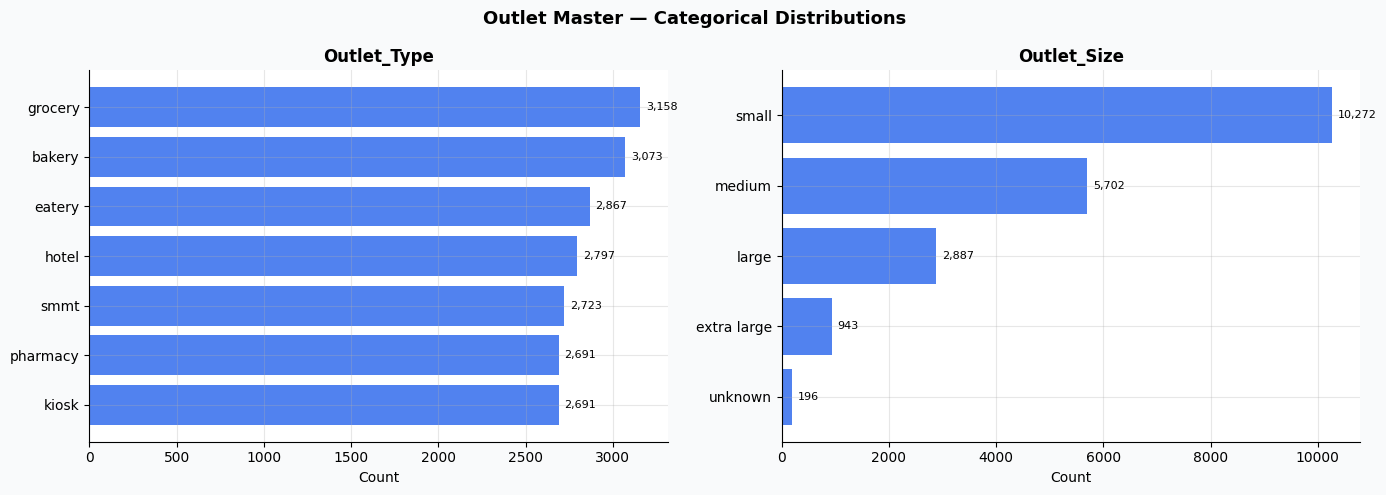

In [13]:
fig = plot_outlet_categorical_breakdown(out)
save_fig(fig, "D1_outlet_categorical_breakdown")
plt.show()

  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\D2_cooler_vs_volume.png


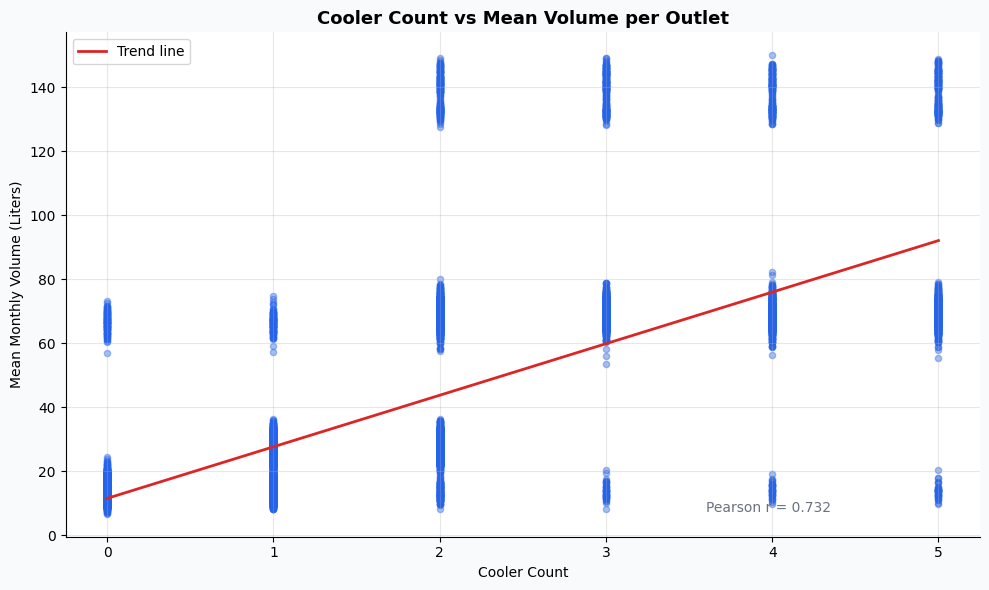

Pearson correlation (Cooler_Count vs mean volume): 0.7320


In [14]:
fig = plot_cooler_vs_volume(tx, out)
save_fig(fig, "D2_cooler_vs_volume")
plt.show()

outlet_mean = tx.groupby("Outlet_ID")["Volume_Liters"].mean().reset_index()
outlet_mean.columns = ["Outlet_ID", "mean_volume"]
merged_corr = outlet_mean.merge(
    out[["Outlet_ID", "Cooler_Count"]], on="Outlet_ID", how="inner"
)
corr_val = merged_corr["Cooler_Count"].corr(merged_corr["mean_volume"])

print(f"Pearson correlation (Cooler_Count vs mean volume): {corr_val:.4f}")
eda_findings["findings"]["cooler_volume_correlation"] = round(float(corr_val), 4)

---
## Section E — Seasonality Analysis

**Question 1:** What is the distribution of the Seasonality_Index labels?
**Question 2:** Do these labels actually correspond to higher/lower volumes?

  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\E1_seasonality_distribution.png


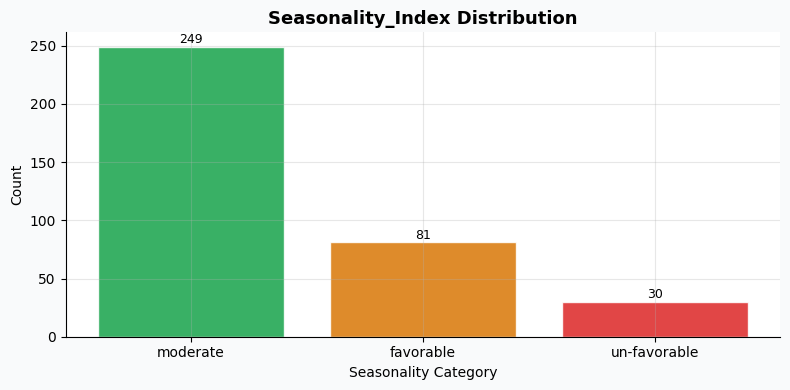

  moderate           249
  favorable           81
  un-favorable        30


In [15]:
fig = plot_seasonality_index_distribution(dist)
save_fig(fig, "E1_seasonality_distribution")
plt.show()

dist_counts = dist["Seasonality_Index"].value_counts().to_dict()
for k, v in dist_counts.items():
    print(f"  {k:<15} {v:>6,}")
eda_findings["findings"]["seasonality_value_counts"] = {
    str(k): int(v) for k, v in dist_counts.items()
}

  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\E2_volume_by_seasonality.png


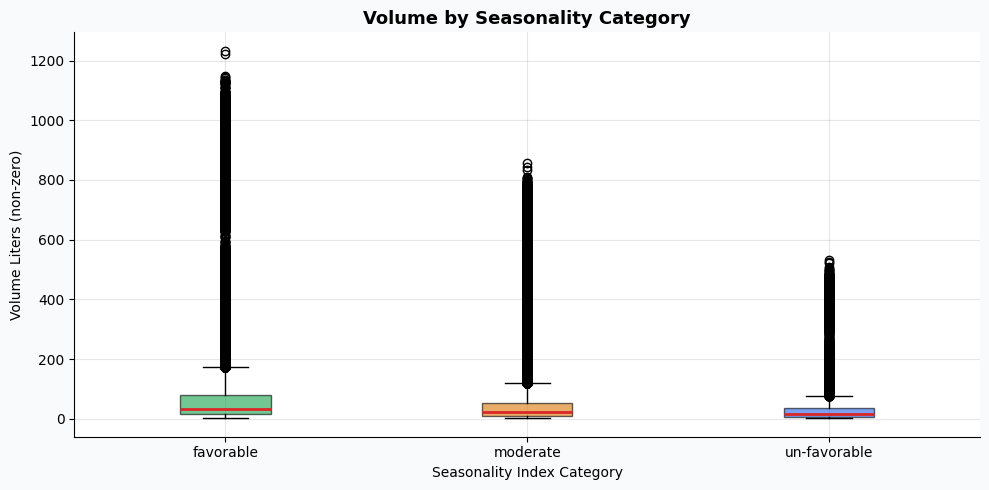

Median Volume_Liters by Seasonality_Index:
Seasonality_Index
favorable       33.1
moderate        23.1
un-favorable    15.0


In [16]:
fig = plot_volume_by_seasonality(tx, dist)
save_fig(fig, "E2_volume_by_seasonality")
plt.show()

merged_seas = tx.merge(
    dist[["Distributor_ID", "Year", "Month", "Seasonality_Index"]],
    on=["Distributor_ID", "Year", "Month"],
    how="left",
)
seas_medians = (
    merged_seas[merged_seas["Volume_Liters"] > 0]
    .groupby("Seasonality_Index")["Volume_Liters"]
    .median()
    .sort_values(ascending=False)
)
print("Median Volume_Liters by Seasonality_Index:")
print(seas_medians.round(1).to_string())
eda_findings["findings"]["seasonality_median_volume"] = seas_medians.round(1).to_dict()

---
## Section F — Holiday Analysis

**Question:** Which months have the most holidays?
High-holiday months may have disrupted deliveries contributing to censored demand.

  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\F1_holidays_per_month.png


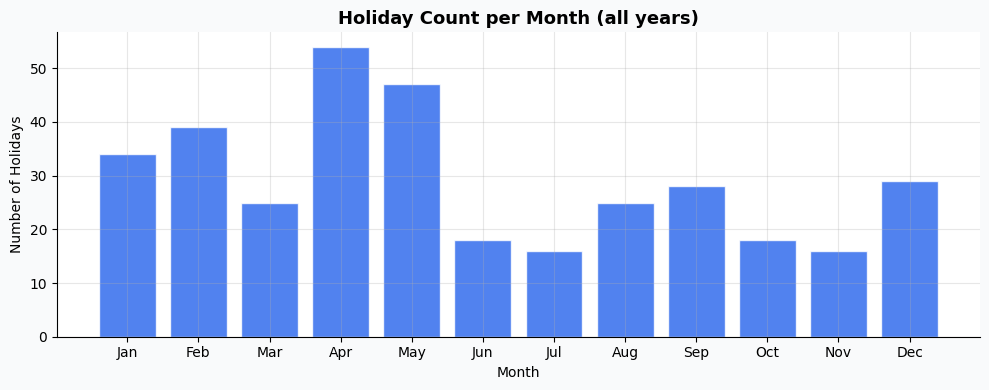

Holiday Type breakdown:


,Holiday_Type,count
0,bank,99
1,public,98
2,mercantile,93
3,poya day,59



January holidays: 34


,Date,Holiday_Name,Holiday_Type
0,2023-01-06 00:00:00+00:00,duruthu full moon poya day,public
1,2023-01-15 00:00:00+00:00,tamil thai pongal day,public
2,2023-01-16 00:00:00+00:00,additional holiday in lieu of tamil thai ponga...,public
26,2023-01-06 00:00:00+00:00,duruthu full moon poya day,poya day
47,2023-01-06 00:00:00+00:00,duruthu full moon poya day,bank
48,2023-01-15 00:00:00+00:00,tamil thai pongal day,bank
49,2023-01-16 00:00:00+00:00,additional holiday in lieu of tamil thai ponga...,bank
73,2023-01-06 00:00:00+00:00,duruthu full moon poya day,mercantile
74,2023-01-15 00:00:00+00:00,tamil thai pongal day,mercantile
75,2023-01-16 00:00:00+00:00,additional holiday in lieu of tamil thai ponga...,mercantile


In [17]:
fig = plot_holidays_per_month(hol)
save_fig(fig, "F1_holidays_per_month")
plt.show()

print("Holiday Type breakdown:")
display(hol["Holiday_Type"].value_counts().reset_index())

jan_holidays = hol[hol["Month"] == 1]
print(f"\nJanuary holidays: {len(jan_holidays)}")
if len(jan_holidays) > 0:
    display(jan_holidays[["Date", "Holiday_Name", "Holiday_Type"]])

eda_findings["findings"]["january_holidays"] = len(jan_holidays)

---
## Section G — Censoring Signal Summary

Consolidates all censoring signals found across EDA.
This table directly motivates our modeling approach in Phase 6.

In [18]:
censoring_df = censoring_signal_summary(tx, outlet_stats)

print("=" * 70)
print("CENSORING SIGNAL SUMMARY")
print("=" * 70)
display(censoring_df)

eda_findings["findings"]["censoring_summary"] = censoring_df.to_dict(orient="records")

CENSORING SIGNAL SUMMARY


,Signal,Count,As % of total rows,Interpretation
0,Zero-volume transactions,N/A,N/A,Possible stockout / missed visit / credit block
1,Flat-volume outlets (CV < 0.05),0,0.0%,Delivery cap likely — true demand may be higher
2,High max/mean ratio (> 3×),19990,100.0%,Low months were constrained; max is closer to ...


### G2 — Outlet Trend Analysis

**Question:** Are outlets growing or declining?
Growing outlets should receive higher potential estimates.

Growing outlets  : 10,937  (54.7%)
Declining outlets: 9,063  (45.3%)
  Saved: C:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\datastrom_competition\technova_datastorm_v4\figures\G2_trend_slope_distribution.png


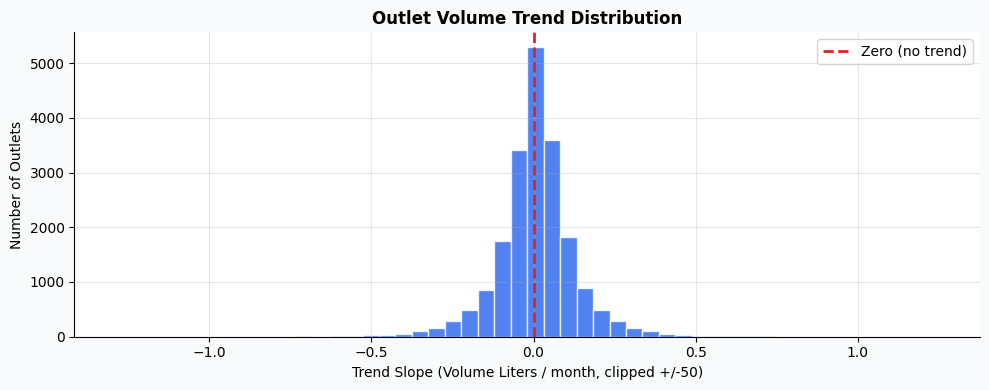

In [19]:
growing = (outlet_stats["trend_slope"] > 0).sum()
declining = (outlet_stats["trend_slope"] <= 0).sum()

print(f"Growing outlets  : {growing:,}  ({100 * growing / len(outlet_stats):.1f}%)")
print(f"Declining outlets: {declining:,}  ({100 * declining / len(outlet_stats):.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    outlet_stats["trend_slope"].clip(-50, 50),
    bins=50,
    color="#2563EB",
    alpha=0.8,
    edgecolor="white",
)
ax.axvline(0, color="#DC2626", linestyle="--", linewidth=2, label="Zero (no trend)")
ax.set_xlabel("Trend Slope (Volume Liters / month, clipped +/-50)")
ax.set_ylabel("Number of Outlets")
ax.set_title("Outlet Volume Trend Distribution", fontsize=12, fontweight="bold")
ax.legend()
fig.tight_layout()
save_fig(fig, "G2_trend_slope_distribution")
plt.show()

eda_findings["findings"]["trend_breakdown"] = {
    "growing_outlets": int(growing),
    "declining_outlets": int(declining),
}